In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,KFold,cross_val_score

# DATA PREPROCESSING

In [2]:
df=pd.read_csv('Finaldf.csv')
df.head()

,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,price
0,2010.0,toyota,corolla s,like new,4 cylinders,gas,152000.0,clean,automatic,4wd,sedan,silver,fl,7900
1,2013.0,hyundai,sonata,excellent,4 cylinders,gas,153622.0,clean,automatic,fwd,sedan,white,il,6850
2,2010.0,ford,taurus,good,6 cylinders,gas,135170.0,clean,automatic,4wd,sedan,white,mi,5995
3,2012.0,gmc,acadia,like new,6 cylinders,gas,60000.0,clean,automatic,4wd,SUV,blue,ca,15000
4,2015.0,chrysler,200,excellent,4 cylinders,gas,132000.0,clean,automatic,4wd,sedan,white,mi,11999


In [3]:
df.dtypes

,0
year,float64
manufacturer,object
model,object
condition,object
cylinders,object
fuel,object
odometer,float64
title_status,object
transmission,object
drive,object


In [4]:
df.isna().sum()

,0
year,0
manufacturer,0
model,0
condition,0
cylinders,0
fuel,0
odometer,0
title_status,0
transmission,0
drive,0


In [5]:
df.shape

(17602, 14)

In [7]:
## Feature encoding
# Manual encoding for ordinal column
condition_map = {
    'salvage':0,
    'fair':1,
    'good':2,
    'excellent':3,
    'like new':4,
    'new':5
}

df['condition'] = df['condition'].map(condition_map)

# Label Encoding remaining categorical columns
le = LabelEncoder()

cat_cols = [
    'manufacturer',
    'model',
    'cylinders',
    'fuel',
    'title_status',
    'transmission',
    'drive',
    'type',
    'paint_color',
    'state'
]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

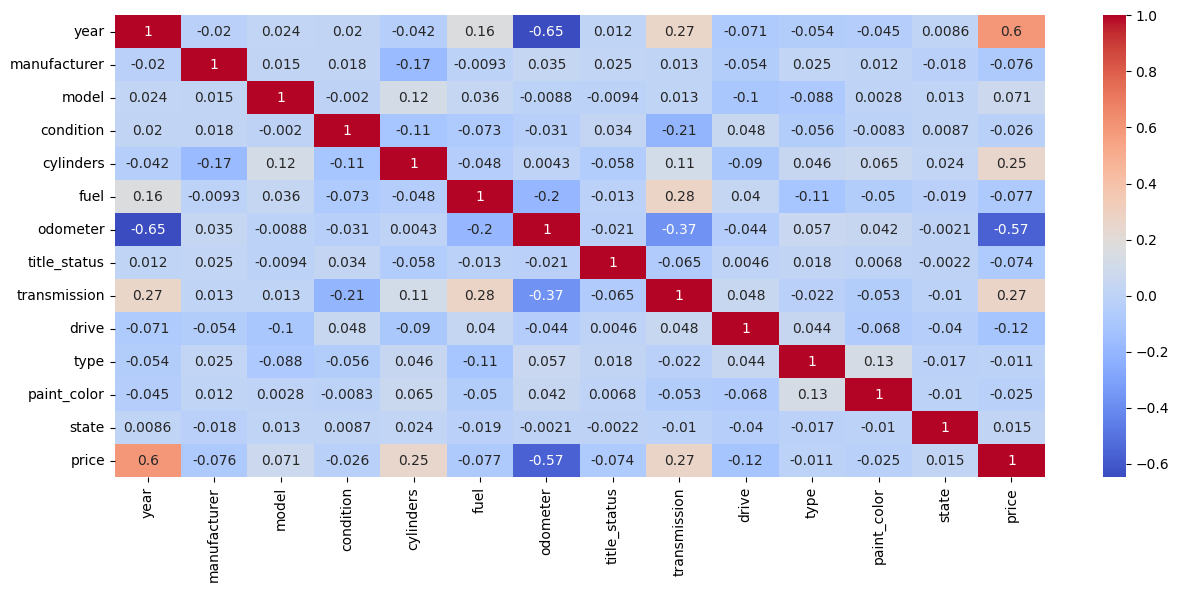

In [13]:
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [ ]:
## TRAIN TEST SPLIT

In [ ]:
x=df.drop('price',axis=1)
y=df['price']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
print('Train Data shape :',x_train.shape,y_train.shape)
print('Test Data shape :',x_test.shape,y_test.shape)

Train Data shape : (14081, 13) (14081,)
Test Data shape : (3521, 13) (3521,)


In [ ]:
## Feature scaling

In [ ]:
sc=StandardScaler()
x_train[['year','odometer']]=sc.fit_transform(x_train[['year','odometer']])
x_test[['year','odometer']]=sc.transform(x_test[['year','odometer']])

In [ ]:
x_train.reset_index(drop=True,inplace=True)
x_test.reset_index(drop=True,inplace=True)
y_train.reset_index(drop=True,inplace=True)
y_test.reset_index(drop=True,inplace=True)

#REGRESSION MODEL

# LINEAR REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=lr.predict(x_train)
print('R2 score',r2_score(y_train,y_pred))

R2 score 0.5374291629108664


In [ ]:
lr_pred=lr.predict(x_test)
print('R2 score',r2_score(y_test,lr_pred))
print('MAE',mean_absolute_error(y_test,lr_pred))
print('MSE',mean_squared_error(y_test,lr_pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,lr_pred)))

R2 score 0.552006385045696
MAE 6842.171540113523
MSE 87860271.02566695
RMSE 9373.380981570468


In [ ]:
lr.score(x_test,y_test)

0.552006385045696

# DECISION TREE

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()

In [ ]:
param_grid = {
    'max_depth': [ 10, 20,],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [10, 20], 'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]})

In [ ]:
grid_search.best_params_

{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

In [ ]:
grid_search.best_score_

np.float64(0.6825887928816377)

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_log_error

In [ ]:
y_pred=grid_search.predict(x_train)
print('R2 score',r2_score(y_train,y_pred))
print('MAE',mean_absolute_error(y_train,y_pred))
print('MSE',mean_squared_error(y_train,y_pred))
print('RMSE',np.sqrt(mean_squared_error(y_train,y_pred)))

R2 score 0.7848166500253551
MAE 4225.016141340377
MSE 42251392.80606822
RMSE 6500.107138045359


In [ ]:
y_pred=grid_search.predict(x_test)
print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print('MSE',mean_squared_error(y_test,y_pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score 0.7035062083944499
MAE 4965.386128955073
MSE 58148205.72955798
RMSE 7625.497080817616


In [ ]:
## LETS TRAIN MODEL WITH BEST PARAM

In [ ]:
dt_model=DecisionTreeRegressor(**grid_search.best_params_)
dt_model.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=10)

In [ ]:
y_pred=dt_model.predict(x_train)
print('R2 score',r2_score(y_train,y_pred))
print('MAE',mean_absolute_error(y_train,y_pred))
print('MSE',mean_squared_error(y_train,y_pred))
print('RMSE',np.sqrt(mean_squared_error(y_train,y_pred)))

R2 score 0.7848166500253551
MAE 4225.016141340377
MSE 42251392.80606822
RMSE 6500.107138045359


In [ ]:
dt_pred=dt_model.predict(x_test)
print('R2 score',r2_score(y_test,dt_pred))
print('MAE',mean_absolute_error(y_test,dt_pred))
print('MSE',mean_squared_error(y_test,dt_pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,dt_pred)))

R2 score 0.7035475587198169
MAE 4964.241253310978
MSE 58140096.12559829
RMSE 7624.965319632496


# RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()

In [ ]:
param_grid = {
    'n_estimators': [100,300],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [10, 20], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 300]})

In [ ]:
y_pred=grid_search.predict(x_train)
print('R2 score',r2_score(y_train,y_pred))
print('MAE',mean_absolute_error(y_train,y_pred))
print('MSE',mean_squared_error(y_train,y_pred))
print('RMSE',np.sqrt(mean_squared_error(y_train,y_pred)))

R2 score 0.9398450596254029
MAE 1967.2194837455293
MSE 11811462.249714931
RMSE 3436.780797449109


In [ ]:
y_pred=grid_search.predict(x_test)
print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print('MSE',mean_squared_error(y_test,y_pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score 0.7952439008047273
MAE 3984.7311644361544
MSE 40156657.972212404
RMSE 6336.928117961605


In [ ]:
grid_search.best_params_

{'max_depth': 20,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 300}

In [ ]:
grid_search.best_score_

np.float64(0.7701103074644675)

In [ ]:
## LETS TRAIN MODEL WITH BEST PARAM

In [ ]:
rf_model=RandomForestRegressor(**grid_search.best_params_)
rf_model.fit(x_train,y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, n_estimators=300)

In [ ]:
y_pred=rf_model.predict(x_train)
print('R2 score',r2_score(y_train,y_pred))
print('MAE',mean_absolute_error(y_train,y_pred))
print('MSE',mean_squared_error(y_train,y_pred))
print('RMSE',np.sqrt(mean_squared_error(y_train,y_pred)))

R2 score 0.9396778644839288
MAE 1970.500066559759
MSE 11844291.12610578
RMSE 3441.553591927021


In [ ]:
rf_pred=rf_model.predict(x_test)
print('R2 score',r2_score(y_test,rf_pred))
print('MAE',mean_absolute_error(y_test,rf_pred))
print('MSE',mean_squared_error(y_test,rf_pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,rf_pred)))

R2 score 0.7942155533675209
MAE 3997.0176653872504
MSE 40358336.928174116
RMSE 6352.821178671262


# ADABOOST

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
ada=AdaBoostRegressor()


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 1.0]
}

In [ ]:
grid_search = GridSearchCV(estimator=ada, param_grid=param_grid, cv=5)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=AdaBoostRegressor(),
             param_grid={'learning_rate': [0.01, 0.1, 1.0],
                         'n_estimators': [100, 200, 300]})

In [ ]:
y_pred=grid_search.predict(x_train)
print('R2 score',r2_score(y_train,y_pred))
print('MAE',mean_absolute_error(y_train,y_pred))
print('MSE',mean_squared_error(y_train,y_pred))
print('RMSE',np.sqrt(mean_squared_error(y_train,y_pred)))

R2 score 0.5901341039554281
MAE 6563.825699741129
MSE 80477439.23324381
RMSE 8970.921871984161


In [ ]:
y_pred=grid_search.predict(x_test)
print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print('MSE',mean_squared_error(y_test,y_pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score 0.6045546361361716
MAE 6555.408381718836
MSE 77554535.79056787
RMSE 8806.50531088058


In [ ]:
grid_search.best_params_

{'learning_rate': 0.01, 'n_estimators': 200}

In [ ]:
grid_search.best_score_

np.float64(0.5834082504530069)

In [ ]:
##LETS TRAIN MODEL WITH BEST PARAMS

In [ ]:
ada_model=AdaBoostRegressor(**grid_search.best_params_)
ada_model.fit(x_train,y_train)

AdaBoostRegressor(learning_rate=0.01, n_estimators=200)

In [ ]:
y_pred=ada_model.predict(x_train)
print('R2 score',r2_score(y_train,y_pred))
print('MAE',mean_absolute_error(y_train,y_pred))
print('MSE',mean_squared_error(y_train,y_pred))
print('RMSE',np.sqrt(mean_squared_error(y_train,y_pred)))

R2 score 0.5887064315770917
MAE 6584.269669270623
MSE 80757763.64711028
RMSE 8986.532348303781


In [ ]:
ad_pred=ada_model.predict(x_test)
print('R2 score',r2_score(y_test,ad_pred))
print('MAE',mean_absolute_error(y_test,ad_pred))
print('MSE',mean_squared_error(y_test,ad_pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,ad_pred)))

R2 score 0.603563587704526
MAE 6571.103033862727
MSE 77748899.68526942
RMSE 8817.533650929234


#GradientBoostRegressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gb=GradientBoostingRegressor()

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 1.0],
    'max_depth': [3, 4, 5]
}

In [ ]:
grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(),
             param_grid={'learning_rate': [0.01, 0.05, 1.0],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [100, 200, 300]})

In [ ]:
grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300}

In [ ]:
model=grid_search.best_estimator_
y_pred=model.predict(x_train)
print('R2 score',r2_score(y_train,y_pred))

R2 score 0.8649584447699612


In [ ]:
y_pred=model.predict(x_test)
print('R2 score',r2_score(y_test,y_pred))

R2 score 0.8118687896162334


In [ ]:
## LETS TRIN MODEL WITH BEST PARAMS

In [ ]:
gb_model=GradientBoostingRegressor(**grid_search.best_params_)
gb_model.fit(x_train,y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=300)

In [ ]:
y_pred=gb_model.predict(x_train)
print('R2 score',r2_score(y_train,y_pred))
print('MAE',mean_absolute_error(y_train,y_pred))
print('MSE',mean_squared_error(y_train,y_pred))
print('RMSE',np.sqrt(mean_squared_error(y_train,y_pred)))

R2 score 0.8649584447699612
MAE 3273.070297849911
MSE 26515498.507849354
RMSE 5149.320198613536


In [ ]:
gb_pred=gb_model.predict(x_test)
print('R2 score',r2_score(y_test,gb_pred))
print('MAE',mean_absolute_error(y_test,gb_pred))
print('MSE',mean_squared_error(y_test,gb_pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,gb_pred)))


R2 score 0.8120453834829598
MAE 3788.5775476908802
MSE 36861560.06798639
RMSE 6071.372173404163


#XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor
xgb=XGBRegressor()


In [ ]:
param_grid = {
    'n_estimators': [100,200,300],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3,7,10]
}

In [ ]:
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.05], 'max_depth': [3, 7, 10],
                         'n_estimators': [100, 200, 300]})

In [ ]:
grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300}

In [ ]:
y_pred=grid_search.predict(x_train)
print('R2 score',r2_score(y_train,y_pred))

R2 score 0.9146709442138672


In [ ]:
y_pred=grid_search.predict(x_test)
print('R2 score',r2_score(y_test,y_pred))

R2 score 0.8207358121871948


In [ ]:
## LETS TRAIN MODEL WITH PARAMS

In [ ]:
xgb_model=XGBRegressor(**grid_search.best_params_)
xgb_model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred=xgb_model.predict(x_train)
print('R2 score',r2_score(y_train,y_pred))
print('MAE',mean_absolute_error(y_train,y_pred))
print('MSE',mean_squared_error(y_train,y_pred))
print('RMSE',np.sqrt(mean_squared_error(y_train,y_pred)))

R2 score 0.9146709442138672
MAE 2564.8447265625
MSE 16754410.0
RMSE 4093.215117728361


In [ ]:
xgb_pred=xgb_model.predict(x_test)
print('R2 score',r2_score(y_test,xgb_pred))
print('MAE',mean_absolute_error(y_test,xgb_pred))
print('MSE',mean_squared_error(y_test,xgb_pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,xgb_pred)))

R2 score 0.8207358121871948
MAE 3590.88720703125
MSE 35157196.0
RMSE 5929.3503860035125


In [ ]:
comparison={'Model Regression':['Linear Regression','Decision Forest','Random Forest','Adaboost','Gradient','XGBoost'],
            'Accuracy':[
                r2_score(y_test,lr_pred),
                r2_score(y_test,dt_pred),
                r2_score(y_test,rf_pred),
                r2_score(y_test,ad_pred),
                r2_score(y_test,gb_pred),
                r2_score(y_test,xgb_pred)
            ],
            "MSE":[
                mean_squared_error(y_test,lr_pred),
                mean_squared_error(y_test,dt_pred),
                mean_squared_error(y_test,rf_pred),
                mean_squared_error(y_test,ad_pred),
                mean_squared_error(y_test,gb_pred),
                mean_squared_error(y_test,xgb_pred)
            ],
            'MAE':[
                mean_absolute_error(y_test,lr_pred),
                mean_absolute_error(y_test,dt_pred),
                mean_absolute_error(y_test,rf_pred),
                mean_absolute_error(y_test,ad_pred),
                mean_absolute_error(y_test,gb_pred),
                mean_absolute_error(y_test,xgb_pred)
            ],
            "RMSE":[
                np.sqrt(mean_squared_error(y_test,lr_pred)),
                np.sqrt(mean_squared_error(y_test,dt_pred)),
                np.sqrt(mean_squared_error(y_test,rf_pred)),
                np.sqrt(mean_squared_error(y_test,ad_pred)),
                np.sqrt(mean_squared_error(y_test,gb_pred)),
                np.sqrt(mean_squared_error(y_test,xgb_pred))
            ]
            }

In [ ]:
comparison=pd.DataFrame(comparison)

In [ ]:
comparison

,Model Regression,Accuracy,MSE,MAE,RMSE
0,Linear Regression,0.552006,8.786027e+07,6842.171540,9373.380982
1,Decision Forest,0.703548,5.814010e+07,4964.241253,7624.965320
2,Random Forest,0.794216,4.035834e+07,3997.017665,6352.821179
3,Adaboost,0.603564,7.774890e+07,6571.103034,8817.533651
4,Gradient,0.812045,3.686156e+07,3788.577548,6071.372173
5,XGBoost,0.820736,3.515720e+07,3590.887207,5929.350386


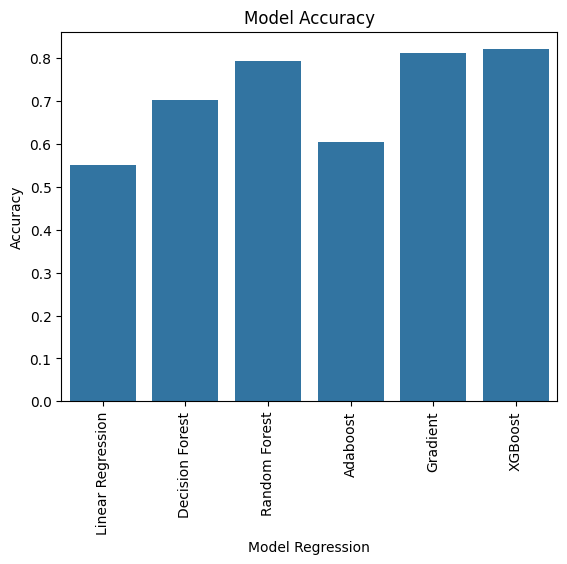

In [ ]:
sns.barplot(x='Model Regression',y='Accuracy',data=comparison)
plt.title('Model Accuracy')
plt.xticks(rotation=90)
plt.show()

In [ ]:
## Will Deploy XGBoost

In [ ]:
importances=xgb_model.feature_importances_

In [ ]:
importance_df=pd.DataFrame({'Feature':x_train.columns,'Importance':importances}).sort_values('Importance',ascending=False)

In [ ]:
importance_df

,Feature,Importance
5,fuel,0.278035
0,year,0.233372
4,cylinders,0.131484
9,drive,0.085031
6,odometer,0.049524
7,title_status,0.047857
8,transmission,0.043523
10,type,0.039933
1,manufacturer,0.033227
2,model,0.027011


In [ ]:
## Lets train a model by removing less importance features it will reduce the complexity

In [ ]:
x_train=x_train.drop(['state','paint_color','condition'],axis=1)
x_test=x_test.drop(['state','paint_color','condition'],axis=1)

In [ ]:
new_model=XGBRegressor(**grid_search.best_params_)
new_model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred=new_model.predict(x_train)
print('R2 score',r2_score(y_train,y_pred))

R2 score 0.9105111956596375


In [ ]:
y_pred=new_model.predict(x_test)
print('R2 score',r2_score(y_test,y_pred))

R2 score 0.8199494481086731


In [ ]:
joblib.dump(xgb,'xgb_model.pkl')

In [ ]:
joblib.dump(new_model,'final_model.pkl')

['final_model.pkl']

In [ ]:
joblib.dump(sc,'sc.pkl')
joblib.dump(le,'le.pkl')
joblib.dump(condition_map,'condition_map.pkl')

['condition_map.pkl']